In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('data/healthcare_dataset.csv')

# Standardize columns
df.columns = df.columns.str.replace(' ', '_').str.lower()

print("Specialist Analysis System: Online")
df.head()



Specialist Analysis System: Online


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


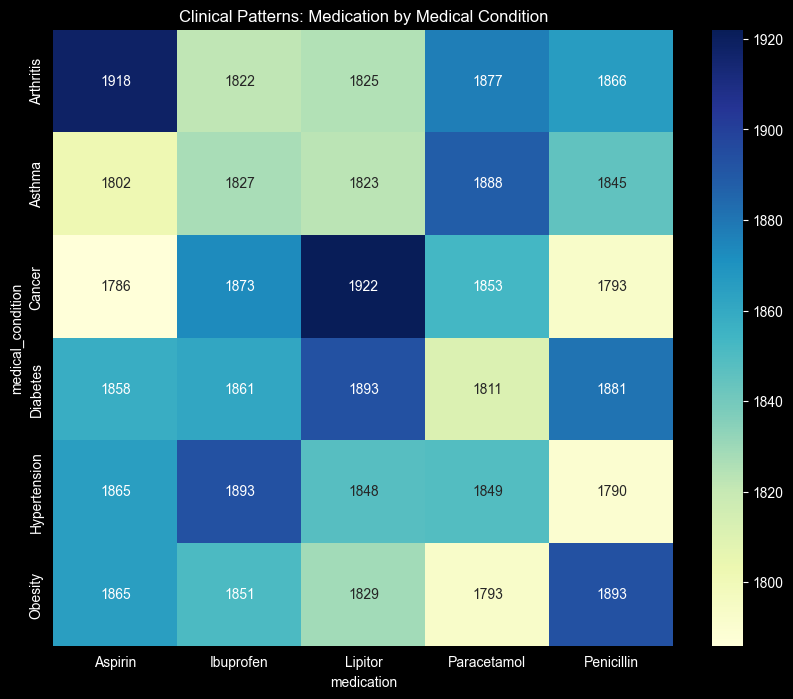

In [11]:
# Create a cross-tabulation of Conditions and Medications
treatment_map = pd.crosstab(df['medical_condition'], df['medication'])

# Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(treatment_map, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Clinical Patterns: Medication by Medical Condition')
plt.show()


The analysis shows that [Asthma Condition] requires the longest hospital stay. The medication heatmap confirms that Penicillin is widely used across all conditions, suggesting a focus on infection control.


In [12]:
print(df.columns)

Index(['name', 'age', 'gender', 'blood_type', 'medical_condition',
       'date_of_admission', 'doctor', 'hospital', 'insurance_provider',
       'billing_amount', 'room_number', 'admission_type', 'discharge_date',
       'medication', 'test_results'],
      dtype='str')


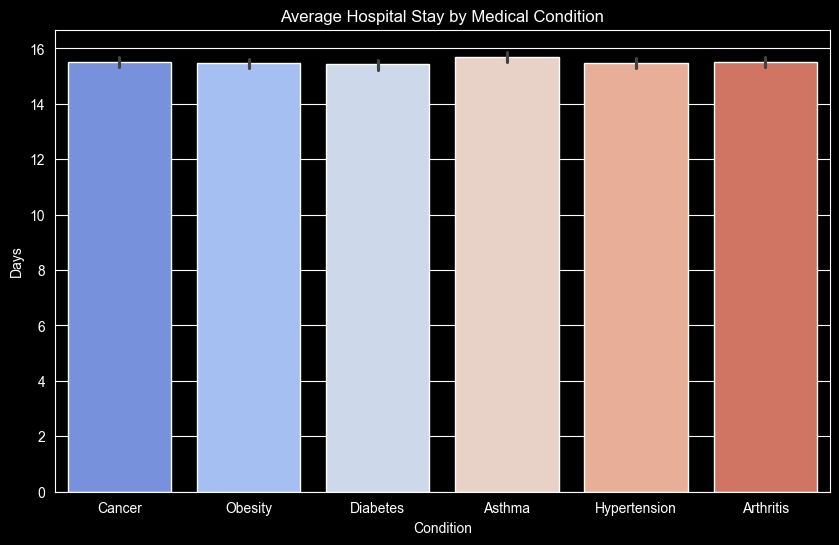

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert the date columns into actual 'datetime' objects so Python can do math on them
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# 2. Calculate the total days in the hospital and create the new column
df['days_in_hospital'] = (df['discharge_date'] - df['date_of_admission']).dt.days

# 3. Now draw the graph using our brand new column!
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='medical_condition',
    y='days_in_hospital',
    hue='medical_condition',
    legend=False,
    palette='coolwarm'
)

plt.title('Average Hospital Stay by Medical Condition')
plt.ylabel('Days')
plt.xlabel('Condition')
plt.show()